In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import torch
from tqdm import tqdm

# Your existing imports
from src.comparing_connectomes.portrait_divergence_comparer import PortraitDivergence

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 4)

print("✅ Imports loaded")

✅ Imports loaded


In [17]:
# Data 
dataset_name = "hcp_schaefer_100_dataset"
experiment_name = "05_second_big_overnight_run_10201"

# Load one generated network
network_path = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/04_big_overnight_run/generated_networks/net_eta-0.444444477558136_gamma0.933333337306976_ruleMatchingIndex_id001.npy") 
# /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/05_second_big_overnight_run_10201/generated_networks/net_eta-0.0799999833107_gamma-0.023000001907349_ruleMatchingIndex_id000.npy")

initial_network = np.load(network_path)
print(f"Network shape: {initial_network.shape}")
print(f"Network density: {initial_network.sum() / (initial_network.shape[0] * initial_network.shape[1]):.4f}")
print(f"Number of edges: {int(initial_network.sum())}")

# Load empirical networks for comparison
empirical_path = Path(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/{dataset_name}/01_connectomes/00_connectomes_density10.npy")
empirical_networks = np.load(empirical_path)


empirical_networks = empirical_networks[:3, :, :]  # Use only first 3 for quick testing


print(f"\nEmpirical networks shape: {empirical_networks.shape}")

# Convert to torch
empirical_tensor = torch.tensor(empirical_networks, dtype=torch.float32)

print("\n✅ Data loaded")

if len(initial_network.shape) == 3:
    initial_network = initial_network[:1,:,:] # Take the first network if 3D

# empirical_networks = empirical_networks[:1, :, :]  # Use only first for quick testing

print(initial_network.shape, empirical_networks.shape)

Network shape: (1, 100, 100)
Network density: 9.9000
Number of edges: 990

Empirical networks shape: (3, 100, 100)

✅ Data loaded
(1, 100, 100) (3, 100, 100)


In [18]:

class SimpleNetworkSA:
    """Ultra-simple SA for debugging."""
    
    def __init__(self, initial_network, empirical_tensor):
        self.initial_network = initial_network.copy()
        self.empirical_tensor = empirical_tensor
        self.evaluator = PortraitDivergence()
        self.target_edges = int(initial_network.sum())
        
    def evaluate(self, network):
        """Calculate portrait divergence."""
        
        # print("Evaluate network:", network.sum())
        network_tensor = torch.tensor(network, dtype=torch.float32) # .unsqueeze(0)
        # print("Network tensor shape:", network_tensor.shape)    
        # print("Empirical tensor shape:", self.empirical_tensor.shape)
        
        metrics = self.evaluator(network_tensor, self.empirical_tensor)
        # Average across all empirical networks
        return np.mean([v for v in metrics.values()])
    
    def perturb_network(self, network, strength=0.05):
        """
        Simple perturbation: randomly flip a few edges.
        
        strength: fraction of edges to potentially flip (0.05 = 5% of edges)
        """
        new_network = network.copy()
        
        n_nodes = network.shape[-1]
        n_perturbations = max(1, int(self.target_edges * strength))
        
        for _ in range(n_perturbations):
            # Pick random edge location (upper triangle only)
            i = np.random.randint(0, n_nodes-1)
            j = np.random.randint(i + 1, n_nodes)
            
            # Flip the edge (0->1 or 1->0)
            new_network[0, i, j] = 1 - new_network[0, i, j]
            new_network[0, j, i] = new_network[0, i, j]  # Keep symmetric

        return new_network
    
    def run(self, initial_temp=1.0, final_temp=0.01, cooling_rate=0.9, max_iter=20):
        """Run simple SA."""
        current_network = self.initial_network.copy()

        current_energy = self.evaluate(current_network)
        
        best_network = current_network.copy()
        best_energy = current_energy
        print("Best energy is initialized to:", best_energy, "current energy:", current_energy)
        
        history = []
        temperature = initial_temp
        iteration = 0
        
        print(f"Initial energy: {current_energy:.6f}")
        
        while temperature > final_temp:
            for _ in range(max_iter):
                # Perturb
                new_network = self.perturb_network(current_network)
                new_energy = self.evaluate(new_network)
                
                print((new_network-current_network).sum(), "new_energy:", new_energy)
                
                # Acceptance
                delta_e = new_energy - current_energy
                if delta_e < 0 or np.random.random() < np.exp(-delta_e / temperature):
                    print("Accepted")
                    
                    current_network = new_network
                    current_energy = new_energy
                    
                    # Update best
                    if current_energy < best_energy:
                        print("Actually changed best network")
                        best_network = current_network.copy()
                        best_energy = current_energy
                        print(f"  Iter {iteration}: New best = {best_energy:.6f}")
                
                history.append({
                    'iteration': iteration,
                    'temperature': temperature,
                    'current_energy': current_energy,
                    'best_energy': best_energy
                })
                iteration += 1
            
            # Cool down
            temperature *= cooling_rate
            print(f"Temperature: {temperature:.4f}, Best: {best_energy:.6f}")
        
        return best_network, best_energy, pd.DataFrame(history)

print("✅ SA class defined")



✅ SA class defined


In [19]:
# Run simulated annealing

print("Running simulated annealing...")
print("=" * 60)

sa = SimpleNetworkSA(initial_network, empirical_tensor)

# Run SA (short for debugging)
optimized_network, optimized_energy, history = sa.run(
    initial_temp=1.0,
    final_temp=0.1,
    cooling_rate=0.85,
    max_iter=150  # Keep it short for debugging
)

print("\n" + "=" * 60)
print("✅ Optimization complete!")
print(f"Historically Initial energy: {history.iloc[0]['current_energy']:.6f}")
print(f"Final energy: {optimized_energy:.6f}")
print(f"Improvement: {history.iloc[0]['current_energy'] - optimized_energy:.6f}")



Running simulated annealing...
Best energy is initialized to: 0.9328940839859077 current energy: 0.9328940839859077
Initial energy: 0.932894
50.0 new_energy: 0.694472947441637
Accepted
Actually changed best network
  Iter 0: New best = 0.694473
70.0 new_energy: 0.49761309630696554
Accepted
Actually changed best network
  Iter 1: New best = 0.497613
58.0 new_energy: 0.3826265199667594
Accepted
Actually changed best network
  Iter 2: New best = 0.382627
62.0 new_energy: 0.4164523169133341
78.0 new_energy: 0.4052691870408907
Accepted
74.0 new_energy: 0.45725744796283835
Accepted
54.0 new_energy: 0.4879206172217525
Accepted
66.0 new_energy: 0.5136060641407445
Accepted
62.0 new_energy: 0.5778948134560541
Accepted
66.0 new_energy: 0.6407400749995502
Accepted
54.0 new_energy: 0.687986747428884
Accepted
58.0 new_energy: 0.7478382774378218
Accepted
66.0 new_energy: 0.755317561476725
Accepted
58.0 new_energy: 0.8119029874018677
Accepted
46.0 new_energy: 0.8405495184698341
Accepted
62.0 new_energ

In [20]:
# Evaluate Both Networks
print("\nEvaluating networks...")

# Evaluate initial
initial_tensor = torch.tensor(initial_network, dtype=torch.float32) # .unsqueeze(0)
initial_metrics = sa.evaluator(initial_tensor, empirical_tensor)
initial_divergence = np.mean([v for v in initial_metrics.values()])

# Evaluate optimized
optimized_tensor = torch.tensor(optimized_network, dtype=torch.float32) # .unsqueeze(0)
optimized_metrics = sa.evaluator(optimized_tensor, empirical_tensor)
optimized_divergence = np.mean([v for v in optimized_metrics.values()])

print(f"\nHistorically Initial portrait divergence: {initial_divergence:.6f}")
print(f"Optimized portrait divergence: {optimized_divergence:.6f}")
print(f"Improvement: {initial_divergence - optimized_divergence:.6f} ({((initial_divergence - optimized_divergence) / initial_divergence * 100):.2f}%)")

print("\n✅ Evaluation complete")



Evaluating networks...

Historically Initial portrait divergence: 0.932894
Optimized portrait divergence: 0.382627
Improvement: 0.550268 (58.98%)

✅ Evaluation complete


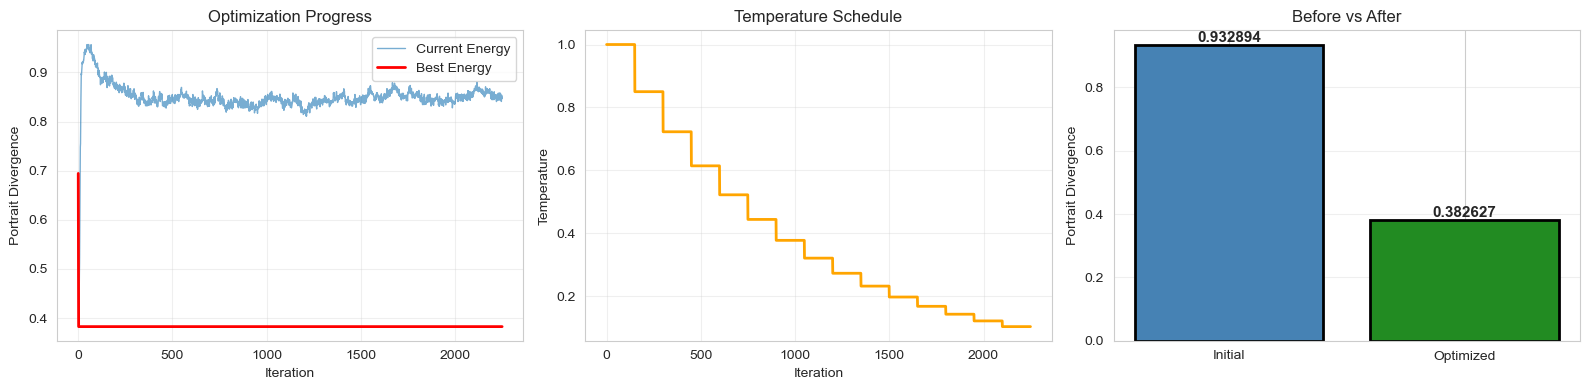

✅ Plots created


In [21]:
# Visualization - Optimization History
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: Energy over iterations
ax = axes[0]
ax.plot(history['iteration'], history['current_energy'], 
        label='Current Energy', alpha=0.6, linewidth=1)
ax.plot(history['iteration'], history['best_energy'], 
        label='Best Energy', linewidth=2, color='red')
ax.set_xlabel('Iteration')
ax.set_ylabel('Portrait Divergence')
ax.set_title('Optimization Progress')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Temperature schedule
ax = axes[1]
ax.plot(history['iteration'], history['temperature'], color='orange', linewidth=2)
ax.set_xlabel('Iteration')
ax.set_ylabel('Temperature')
ax.set_title('Temperature Schedule')
ax.grid(True, alpha=0.3)

# Plot 3: Bar comparison
ax = axes[2]
bars = ax.bar(['Initial', 'Optimized'], 
              [initial_divergence, optimized_divergence],
              color=['steelblue', 'forestgreen'],
              edgecolor='black',
              linewidth=2)
ax.set_ylabel('Portrait Divergence')
ax.set_title('Before vs After')
ax.grid(True, alpha=0.3, axis='y')

# Add values on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.6f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ Plots created")

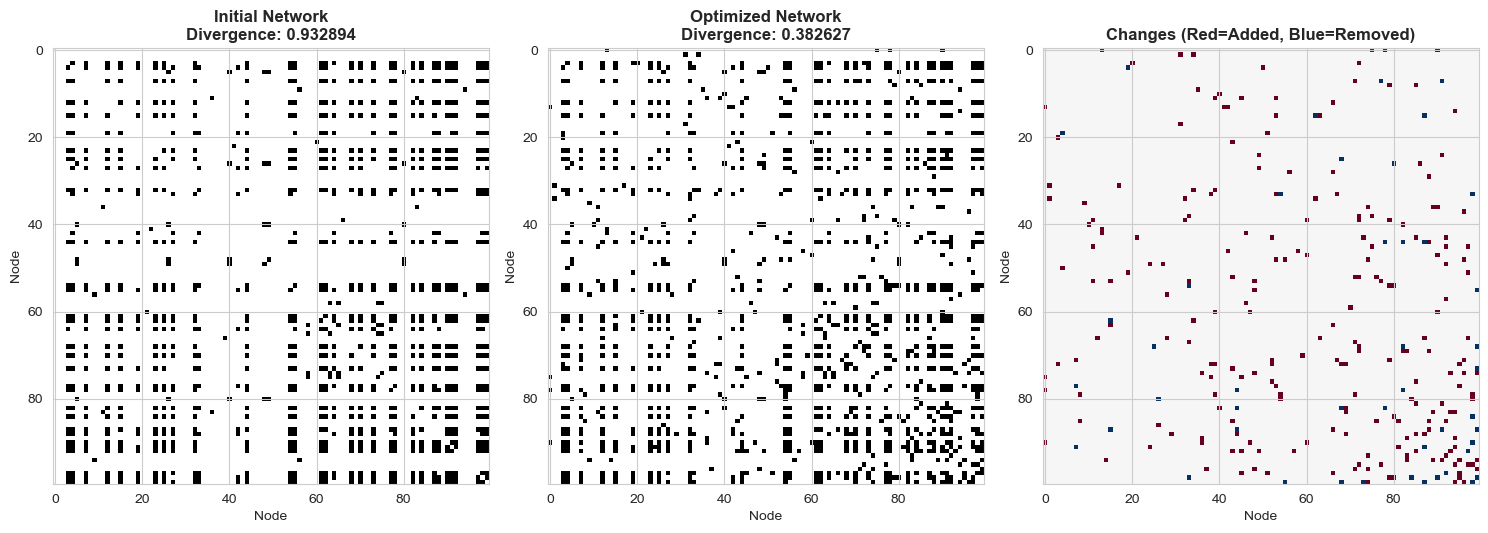


Network changes:
  Edges added: 224
  Edges removed: 46
  Net change: 178
  Total changes: 270

✅ Network visualizations complete


In [22]:
# Visualize Network Changes
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Initial network
ax = axes[0]
ax.imshow(initial_network[0,:,:], cmap='Greys', interpolation='nearest')
ax.set_title(f'Initial Network\nDivergence: {initial_divergence:.6f}', fontsize=12, fontweight='bold')
ax.set_xlabel('Node')
ax.set_ylabel('Node')

# Optimized network
ax = axes[1]
ax.imshow(optimized_network[0,:,:], cmap='Greys', interpolation='nearest')
ax.set_title(f'Optimized Network\nDivergence: {optimized_divergence:.6f}', fontsize=12, fontweight='bold')
ax.set_xlabel('Node')
ax.set_ylabel('Node')

# Difference (what changed)
ax = axes[2]
difference = optimized_network[0,:,:] - initial_network[0,:,:]
ax.imshow(difference, cmap='RdBu_r', interpolation='nearest', vmin=-1, vmax=1)
ax.set_title('Changes (Red=Added, Blue=Removed)', fontsize=12, fontweight='bold')
ax.set_xlabel('Node')
ax.set_ylabel('Node')
# plt.colorbar(im, ax=ax, label='Edge Change')

plt.tight_layout()
plt.show()

# Summary statistics
n_added = (difference == 1).sum()
n_removed = (difference == -1).sum()
print(f"\nNetwork changes:")
print(f"  Edges added: {n_added}")
print(f"  Edges removed: {n_removed}")
print(f"  Net change: {n_added - n_removed}")
print(f"  Total changes: {n_added + n_removed}")

print("\n✅ Network visualizations complete")

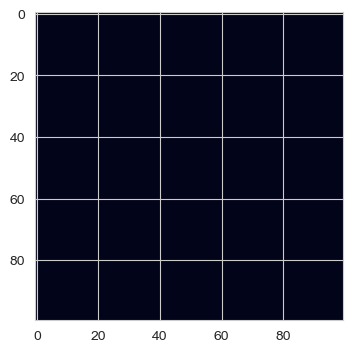

In [16]:
# Load one generated network
network_path = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/05_second_big_overnight_run_10201/generated_networks/net_eta-0.0799999833107_gamma-0.023000001907349_ruleMatchingIndex_id000.npy")

initial_network = np.load(network_path)
plt.imshow(optimized_network[0,:,:] - initial_network[0,:,:])

In [9]:

# Cell 8: (Optional) Save Results
# Uncomment to save results
"""
output_dir = Path("./sa_debug_output")
output_dir.mkdir(exist_ok=True)

# Save networks
np.save(output_dir / "initial_network.npy", initial_network)
np.save(output_dir / "optimized_network.npy", optimized_network)

# Save history
history.to_csv(output_dir / "optimization_history.csv", index=False)

# Save metrics
metrics_df = pd.DataFrame({
    'network': ['initial', 'optimized'],
    'portrait_divergence': [initial_divergence, optimized_divergence]
})
metrics_df.to_csv(output_dir / "metrics.csv", index=False)

print(f"✅ Results saved to {output_dir}")
"""

print("\n🎉 All done! Notebook complete.")


🎉 All done! Notebook complete.


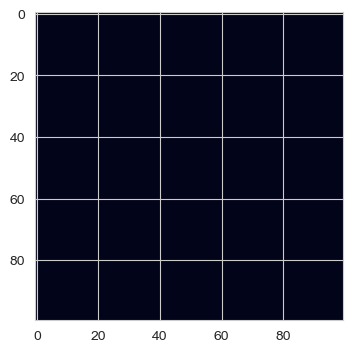

In [20]:
plt.imshow(optimized_network[0,:,:])
plt.imshow(initial_network[0,:,:])
plt.imshow(optimized_network[0,:,:]-initial_network[0,:,:])

In [24]:

import numpy as np
import pandas as pd
import torch
from pathlib import Path
from tqdm import tqdm
import re
from typing import Dict, List, Tuple, Optional, Set
import csv
from multiprocessing import Pool

from src.config.path import PathConfig
from src.config.GNM import create_evaluation_criteria
from src.comparing_connectomes.base_comparer import NetworkEvaluator
from src.comparing_connectomes.energy_comparer import EnergyEvaluator
from src.comparing_connectomes.portrait_divergence_comparer import PortraitDivergence
from src.comparing_connectomes.f1_comparer import F1Evaluator
from src.comparing_connectomes.communicability_comparer import CommunicabilityEvaluator

from src.comparing_connectomes.complete_comparison_script import *

In [25]:
optimized_network.shape

(1, 100, 100)

In [30]:
reference_csv_path

PosixPath('/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/drafts_and_one_time_plots/output/gnm/hcp_schaefer_100_dataset/04_big_overnight_run/all_metrics_for_04_big_overnight_run.csv')

In [34]:
dataset_name="hcp_schaefer_100_dataset"
experiment_name="04_big_overnight_run" # 80_more_animals_animal_169" # 103", # 06_with_seeds", # 05_second_big_overnight_run_10201", 
evaluation_mode="portrait" # communicability", # f1", # portrait",  # or "energy"
# debug_subject_ids=None # [0,1,2,3,4,5,6,7,8,9] #None,  # turn this to "None" if not in debug mode. Or array [1,2,]
number_multiprocessing_processes=8

        
path_config = PathConfig( 
    dataset_name=dataset_name,
    experiment_name=experiment_name, 
)

path_01_connectomes = Path(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/{dataset_name}/01_connectomes") 

empirical_networks_path = path_01_connectomes / "00_connectomes_density10.npy"
distance_matrices_path = path_config.dir_02_distance_matrices / "distance_matrix_100.npy"

generated_networks_dir = path_config.output_experiment_dir / "generated_networks"

legacy_csv = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/04_big_overnight_run/all_metrics_for_04_big_overnight_run.csv") # path_config.output_experiment_dir / f"all_metrics_for_{experiment_name}.csv"
reference_csv_path = legacy_csv

print(f"Using reference CSV: {reference_csv_path}")

config_dict = {
    'gnm': {
        'evaluation_metrics': ['degree_ks', 'clustering_ks', 'edge_length_ks', 'betweenness_ks']
    }
}

output_dir = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/04_big_overnight_run")

output_path = output_dir / f"summary_indiv_{evaluation_mode}_for_exp_{experiment_name}.csv"


# LOAD NETWORKS
print("\n" + "=" * 60)
print("LOADING NETWORKS")
print("=" * 60)

# Load empirical networks first to know how many subjects we have
# empirical_networks = load_empirical_networks(empirical_networks_path)
empirical_networks = optimized_network
num_subjects = empirical_networks.shape[0]

# Determine metric prefix
metric_prefix = evaluation_mode  # 'energy' or 'portrait'

# Check which subjects have already been processed
processed_subject_ids = get_processed_subject_ids(output_path, metric_prefix, num_subjects)

# Determine which subjects still need processing
all_subject_ids = set(range(num_subjects))
subjects_to_process = sorted(all_subject_ids - processed_subject_ids)

# if debug_subject_ids is not None:
#     subjects_to_process = [s for s in subjects_to_process if s in debug_subject_ids]

# print(f"\n📋 Subject processing status:")
# print(f"   Total subjects: {num_subjects}")
# print(f"   Already processed: {len(processed_subject_ids)}")
# print(f"   To process: {len(subjects_to_process)}")
# print(f"   Subject IDs to process: {subjects_to_process}")

# if len(subjects_to_process) == 0:
#     print("✅ All subjects have been processed!")
#     return pd.read_csv(output_path) if output_path.exists() else None

# df_prior_results, already_processed_files = load_existing_results(output_path)

networks_dir = Path(generated_networks_dir)
all_network_files = sorted(networks_dir.glob("net_eta*.npy"))

# # If we have prior results, only process networks that are already in the CSV
# # This ensures we add columns to existing rows
# if df_prior_results is not None and 'filename' in df_prior_results.columns:
#     filenames_in_csv = set(df_prior_results['filename'].values)
#     network_files_to_process = [f for f in all_network_files if f.name in filenames_in_csv]
#     print(f"Found {len(network_files_to_process)} networks already in CSV")
# else:
#     # Process all networks if no prior results
#     network_files_to_process = all_network_files
#     print(f"Found {len(network_files_to_process)} total network files")

# Load and order networks according to reference CSV
df_reference_order = pd.read_csv(reference_csv_path)

if 'id' in df_reference_order.columns:
    list_eta_gamma_id_reference = list(zip(
        df_reference_order["eta"], 
        df_reference_order["gamma"],
        df_reference_order["id"]
    ))
else:
    list_eta_gamma_id_reference = [
        (eta, gamma, 0) 
        for eta, gamma in zip(df_reference_order["eta"], df_reference_order["gamma"])
    ]

ordered_files_to_process = []
for eta, gamma, net_id in list_eta_gamma_id_reference:
    net_id_str = f"{net_id:03d}"
    filename = f"net_eta{eta}_gamma{gamma}_ruleMatchingIndex_id{net_id_str}.npy"
    filepath = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/04_big_overnight_run/generated_networks") / filename
    
    if filepath.exists():
        ordered_files_to_process.append(filepath)

print(f"Processing {len(ordered_files_to_process)} networks in reference order...")

generated_networks = []
generated_network_parameters = []
filenames = []

for filepath in ordered_files_to_process:
    try:
        network = np.load(filepath)
        params = extract_params_from_filename(filepath.name)
        
        generated_networks.append(network)
        generated_network_parameters.append(params)
        filenames.append(filepath.name)
    except Exception as e:
        print(f"⚠️ Warning: Could not load {filepath.name}: {e}")
        continue


generated_networks = np.stack(generated_networks)

if generated_networks.shape[-1] != empirical_networks.shape[-1]:
    raise ValueError(
        f"Dimension mismatch: Generated networks have {generated_networks.shape[-1]} nodes "
        f"but empirical networks have {empirical_networks.shape[-1]} nodes."
    )

# INITIALIZE EVALUATOR
print("\n" + "=" * 60)
print("INITIALIZING EVALUATOR")
print("=" * 60)

if evaluation_mode == "portrait":
    evaluator = PortraitDivergence()
    print("Using Portrait Divergence evaluation")
elif evaluation_mode == "f1":
    evaluator = F1Evaluator()
    print("Using F1 evaluation")
elif evaluation_mode == "communicability":
    evaluator = CommunicabilityEvaluator()
    print("Using Communicability evaluation")
elif evaluation_mode == "energy":
    print("Loading distance matrices...")
    distance_matrices = np.load(distance_matrices_path)
    distance_matrices = torch.tensor(distance_matrices, dtype=torch.float32)
    if dataset_name in ["shafiei_human_consensus_dataset", "hcp_schaefer_100_dataset"]: 
        distance_matrices = distance_matrices.unsqueeze(0)
        print("Note: Distance matrix unsqueezed for this dataset")
    print(f"Loaded distance matrix with shape: {distance_matrices.shape}")
    
    evaluation_criteria_list = create_evaluation_criteria_list(
        distance_matrices=distance_matrices,
        config_dict=config_dict
    )
    evaluator = EnergyEvaluator(evaluation_criteria_list)
    print("Using Energy evaluation")    
else:
    raise ValueError(f"Unknown evaluation mode: {evaluation_mode}")

# COMPARE NETWORKS
print("\n" + "=" * 60)
print(f"COMPARING NETWORKS AGAINST {len(subjects_to_process)} NEW SUBJECTS")
print("=" * 60)

print("Converting empirical networks to torch tensors...")
empirical_networks_tensor = torch.tensor(empirical_networks, dtype=torch.float32)

print("Preparing tasks...")
tasks = []
for net_idx, (network, params, filename) in enumerate(zip(
    generated_networks, 
    generated_network_parameters,
    filenames
)):
    task_args = (
        net_idx,
        network,
        params,
        filename,
        empirical_networks_tensor,
        evaluator,
        subjects_to_process  # Only evaluate against subjects that need processing
    )
    tasks.append(task_args)

print(f"\nProcessing {len(tasks)} networks against {len(subjects_to_process)} subjects...")

all_results = []

with Pool(processes=number_multiprocessing_processes) as pool:
    for result in tqdm(
        pool.imap(process_network_for_subjects, tasks), 
        total=len(tasks), 
        desc="Evaluating networks"
    ):
        all_results.append(result)

all_results
# Merge new columns into existing CSV
# merge_new_columns_to_csv(output_path, all_results)

# print(f"\n✅ All results saved to: {output_path}")

# results_df = pd.read_csv(output_path) if output_path.exists() else None

# # SUMMARY
# print("\n" + "=" * 60)
# print("SUMMARY")
# print("=" * 60)
# if results_df is not None:
#     print(f"Total networks in file: {len(results_df)}")
    
#     # Count how many subjects have been fully processed
#     subject_columns = [col for col in results_df.columns if col.startswith(f'{metric_prefix}_subject_')]
#     num_subjects_in_file = len(subject_columns)
    
#     print(f"Subjects processed: {num_subjects_in_file}/{num_subjects}")
#     print(f"Parameter ranges:")
#     print(f"  eta: [{results_df['eta'].min():.3f}, {results_df['eta'].max():.3f}]")
#     print(f"  gamma: [{results_df['gamma'].min():.3f}, {results_df['gamma'].max():.3f}]")
#     if 'id' in results_df.columns:
#         print(f"  id range: [{results_df['id'].min():.0f}, {results_df['id'].max():.0f}]")
#     print(f"\nFirst few rows of results:")
#     print(results_df.head())
# else: 
#     print("⚠️ Attention: results_df is empty.")

# print("\n✅ Comparison complete!")



Using reference CSV: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/04_big_overnight_run/all_metrics_for_04_big_overnight_run.csv

LOADING NETWORKS
Processing 20000 networks in reference order...

INITIALIZING EVALUATOR
Using Portrait Divergence evaluation

COMPARING NETWORKS AGAINST 1 NEW SUBJECTS
Converting empirical networks to torch tensors...
Preparing tasks...

Processing 20000 networks against 1 subjects...


Evaluating networks:   0%|          | 0/20000 [00:06<?, ?it/s]


IndexError: index 1 is out of bounds for axis 0 with size 1